Sử dụng K-cross validation test cho từng model bậc 1,2,3,4,5


Chuyển file Expectation values tương ứng với true values qua thành x_train và y_train

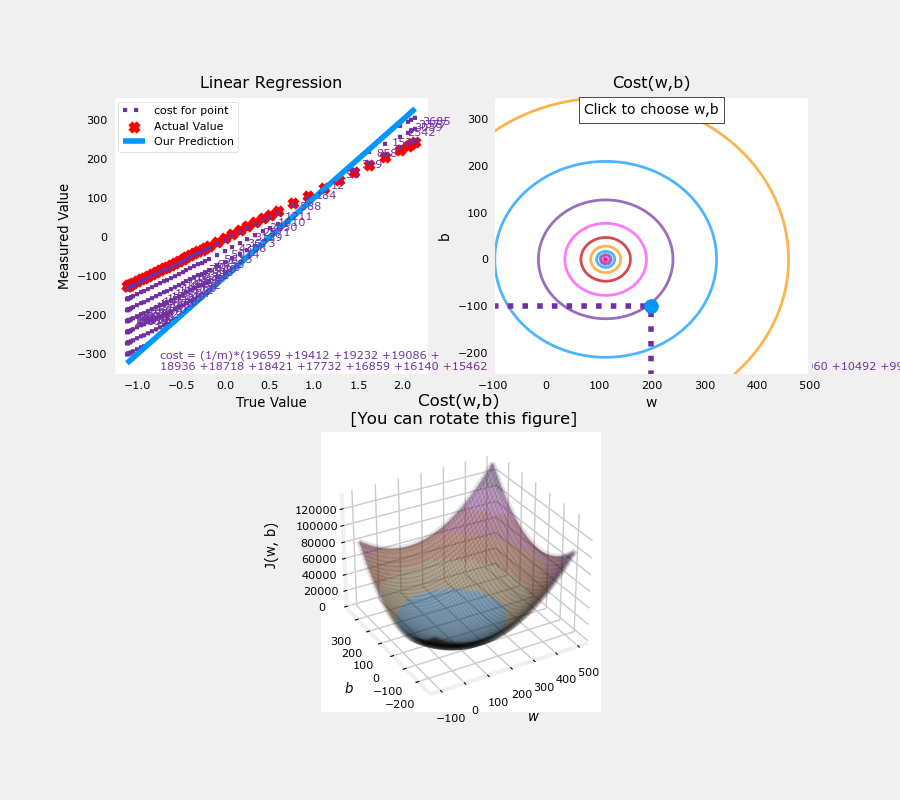

In [14]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
import pandas as pd
x_train = np.array([
    2, 3, 4, 5, 6, 8, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 
    60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 120, 130, 
    140, 150, 160, 170, 180, 190, 200, 220, 240, 260, 280, 
    300, 320, 340, 360, 370, 375, 380
])

y_train = np.array([
    2.782325, 3.25935, 4.067545, 5.04757, 6.001975, 8.326895, 
    10.236335, 15.23321, 19.16292, 23.82822, 28.634885, 33.47087, 
    38.24309, 43.087885, 47.57985, 52.06106, 56.979895, 61.867765, 
    66.620375, 71.474615, 76.4032, 81.338595, 85.72017, 90.860385, 
    95.48461, 100.976285, 104.3609942, 115.81523, 125.367865, 
    135.302295, 145.42794, 156.20736, 165.91558, 175.484755, 
    185.44674, 195.15566, 214.725685, 234.09771, 254.23034, 
    273.649395, 293.15766, 311.469805, 332.2342118, 350.567955, 
    361.148005, 365.54858, 370.504295
])
mx, sx = x_train.mean(), x_train.std()
my     = y_train.mean()
x_s    = (x_train - mx)/sx
y_s    = (y_train - my)
# dùng x_s, y_s cho các hàm vẽ

from render_figure import plt_intuition, plt_stationary, plt_update_onclick, soup_bowl, plt_gradients
plt.style.use('./deeplearning.mplstyle')
plt.close('all') 
fig, ax, dyn_items = plt_stationary(x_s, y_s)
updater = plt_update_onclick(fig, ax, x_s, y_s, dyn_items)

In [15]:
def compute_cost(x, y, w, b): 
    """
    Computes the cost function for linear regression.
    
    Args:
      x (ndarray (m,)): Data, m examples 
      y (ndarray (m,)): target values
      w,b (scalar)    : model parameters  
    
    Returns
        total_cost (float): The cost of using w,b as the parameters for linear regression
               to fit the data points in x and y
    """
    # number of training examples
    m = x.shape[0] 
    
    cost_sum = 0 
    for i in range(m): 
        f_wb = w * x[i] + b   
        cost = (f_wb - y[i]) ** 2  
        cost_sum = cost_sum + cost  
    total_cost = (1 / (2 * m)) * cost_sum  

    return total_cost

In [16]:
import math, copy
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')
from render_figure import plt_house_x, plt_contour_wgrad, plt_divergence, plt_gradients

In [18]:
def compute_gradient(x, y, w, b): 
    """
    Computes the gradient for linear regression 
    Args:
      x (ndarray (m,)): Data, m examples 
      y (ndarray (m,)): target values
      w,b (scalar)    : model parameters  
    Returns
      dj_dw (scalar): The gradient of the cost w.r.t. the parameters w
      dj_db (scalar): The gradient of the cost w.r.t. the parameter b     
     """
    
    # Number of training examples
    m = x.shape[0]    
    dj_dw = 0
    dj_db = 0
    
    for i in range(m):  
        f_wb = w * x[i] + b 
        dj_dw_i = (f_wb - y[i]) * x[i] 
        dj_db_i = f_wb - y[i] 
        dj_db += dj_db_i
        dj_dw += dj_dw_i 
    dj_dw = dj_dw / m 
    dj_db = dj_db / m 
        
    return dj_dw, dj_db

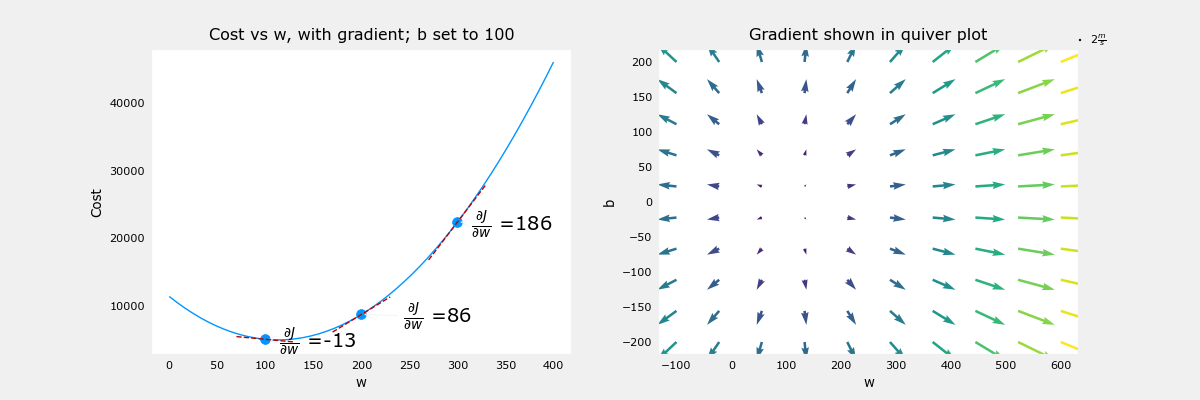

In [20]:
plt_gradients(x_s,y_s, compute_cost, compute_gradient)
plt.show()

In [21]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function): 
    """
    Performs gradient descent to fit w,b. Updates w,b by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      x (ndarray (m,))  : Data, m examples 
      y (ndarray (m,))  : target values
      w_in,b_in (scalar): initial values of model parameters  
      alpha (float):     Learning rate
      num_iters (int):   number of iterations to run gradient descent
      cost_function:     function to call to produce cost
      gradient_function: function to call to produce gradient
      
    Returns:
      w (scalar): Updated value of parameter after running gradient descent
      b (scalar): Updated value of parameter after running gradient descent
      J_history (List): History of cost values
      p_history (list): History of parameters [w,b] 
      """
    
    w = copy.deepcopy(w_in) # avoid modifying global w_in
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    p_history = []
    b = b_in
    w = w_in
    
    for i in range(num_iters):
        # Calculate the gradient and update the parameters using gradient_function
        dj_dw, dj_db = gradient_function(x, y, w , b)     

        # Update Parameters using equation (3) above
        b = b - alpha * dj_db                            
        w = w - alpha * dj_dw                            

        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            J_history.append( cost_function(x, y, w , b))
            p_history.append([w,b])
        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                  f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                  f"w: {w: 0.3e}, b:{b: 0.5e}")
 
    return w, b, J_history, p_history #return w and J,w history for graphing

In [33]:
# initialize parameters
w_init = 0
b_init = 0
# some gradient descent settings
iterations = 10000
tmp_alpha = 1.0e-2
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_s ,y_s, w_init, b_init, tmp_alpha, 
                                                    iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")
def convert_to_original_params(w_s, b_s, mx, sx, my):
    w = w_s / sx
    b = my + b_s - w * mx
    return w, b
w, b = convert_to_original_params(w_final, b_final, mx, sx, my)
print(w, b) 

Iteration    0: Cost 6.30e+03  dj_dw: -1.133e+02, dj_db: -2.782e-14   w:  1.133e+00, b: 2.78170e-16
Iteration 1000: Cost 3.95e-01  dj_dw: -4.893e-03, dj_db: -6.992e-16   w:  1.133e+02, b: 2.48361e-14
Iteration 2000: Cost 3.95e-01  dj_dw: -2.112e-07, dj_db:  3.779e-17   w:  1.133e+02, b: 2.48493e-14
Iteration 3000: Cost 3.95e-01  dj_dw: -9.114e-12, dj_db: -4.535e-16   w:  1.133e+02, b: 2.48594e-14
Iteration 4000: Cost 3.95e-01  dj_dw: -7.011e-13, dj_db: -1.890e-17   w:  1.133e+02, b: 2.48662e-14
Iteration 5000: Cost 3.95e-01  dj_dw: -7.011e-13, dj_db: -1.890e-17   w:  1.133e+02, b: 2.48646e-14
Iteration 6000: Cost 3.95e-01  dj_dw: -7.011e-13, dj_db: -1.890e-17   w:  1.133e+02, b: 2.48631e-14
Iteration 7000: Cost 3.95e-01  dj_dw: -7.011e-13, dj_db: -1.890e-17   w:  1.133e+02, b: 2.48616e-14
Iteration 8000: Cost 3.95e-01  dj_dw: -7.011e-13, dj_db: -1.890e-17   w:  1.133e+02, b: 2.48601e-14
Iteration 9000: Cost 3.95e-01  dj_dw: -7.011e-13, dj_db: -1.890e-17   w:  1.133e+02, b: 2.48586e-14


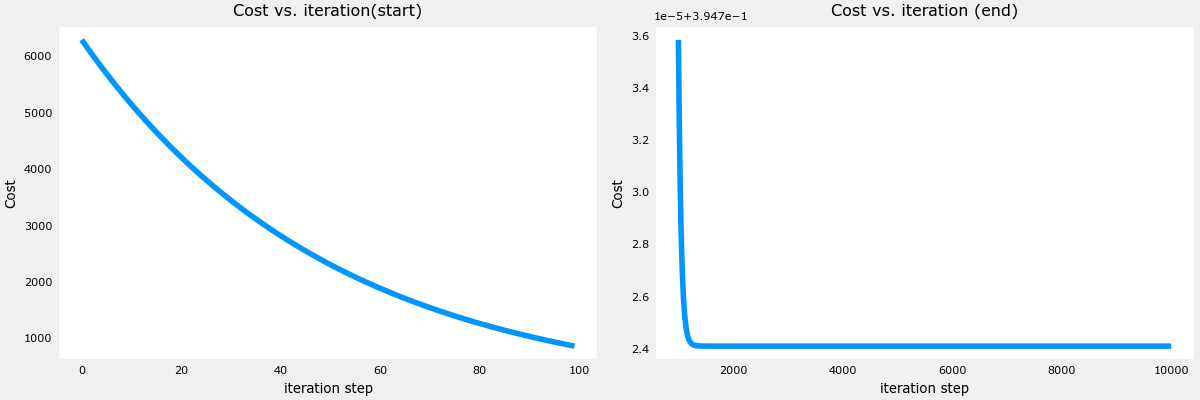

In [24]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_hist[:100])
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step') 
plt.show()

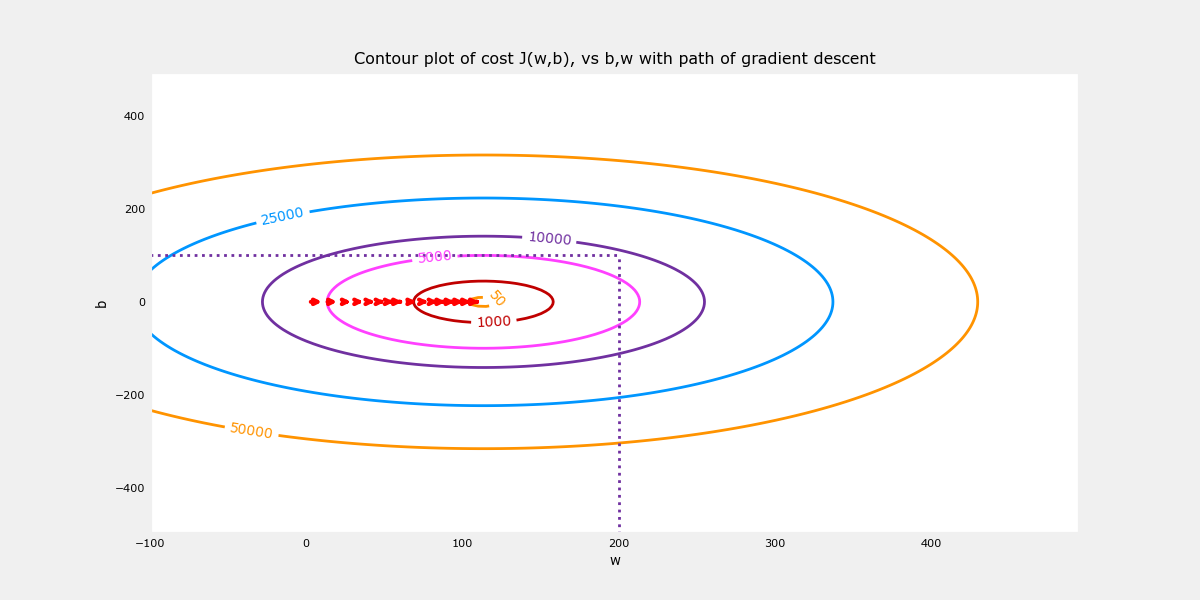

In [26]:
fig, ax = plt.subplots(1,1, figsize=(12, 6))
plt_contour_wgrad(x_s, y_s, p_hist, ax)

In [27]:
# initialize parameters
w_init = 0
b_init = 0
# set alpha to a large value
iterations = 10
tmp_alpha = 8.0e-1
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha, 
                                                    iterations, compute_cost, compute_gradient)

Iteration    0: Cost 8.78e+12  dj_dw: -2.990e+04, dj_db: -1.275e+02   w:  2.392e+04, b: 1.02035e+02
Iteration    1: Cost 5.30e+21  dj_dw:  7.342e+08, dj_db:  3.141e+06   w: -5.874e+08, b:-2.51286e+06
Iteration    2: Cost 3.19e+30  dj_dw: -1.803e+13, dj_db: -7.715e+10   w:  1.443e+13, b: 6.17157e+10
Iteration    3: Cost 1.93e+39  dj_dw:  4.429e+17, dj_db:  1.895e+15   w: -3.543e+17, b:-1.51573e+15
Iteration    4: Cost 1.16e+48  dj_dw: -1.088e+22, dj_db: -4.653e+19   w:  8.701e+21, b: 3.72264e+19
Iteration    5: Cost 7.01e+56  dj_dw:  2.671e+26, dj_db:  1.143e+24   w: -2.137e+26, b:-9.14277e+23
Iteration    6: Cost 4.23e+65  dj_dw: -6.561e+30, dj_db: -2.807e+28   w:  5.249e+30, b: 2.24546e+28
Iteration    7: Cost 2.55e+74  dj_dw:  1.611e+35, dj_db:  6.894e+32   w: -1.289e+35, b:-5.51484e+32
Iteration    8: Cost 1.54e+83  dj_dw: -3.958e+39, dj_db: -1.693e+37   w:  3.166e+39, b: 1.35444e+37
Iteration    9: Cost 9.28e+91  dj_dw:  9.720e+43, dj_db:  4.158e+41   w: -7.776e+43, b:-3.32650e+41


NameError: name 'w' is not defined